In [1]:
from PIL import Image

import torch

import numpy as np

In [2]:
from gdino import GDINO

/home/crest/Documents/Github/PotatoScan/3dscan/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
gdino_model = GDINO()
gdino_model.build_model(device="cuda")

One or both local paths not provided. Loading from Hugging Face Hub: IDEA-Research/grounding-dino-base


In [152]:
objects = ["potato tuber"]

In [153]:
texts_prompt = ". ".join(objects)
texts_prompt

'potato tuber'

In [142]:
# image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160444_5510.jpg"
image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160435_5485.jpg"
# image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/084/001/DSC_001_20251002_160325_5370.jpg"
# image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/084/004/DSC_004_20251002_160326_5373.jpg"

image_pil = Image.open(image_file)

In [143]:
gdino_results = gdino_model.predict([image_pil], [texts_prompt], box_threshold=0.3, text_threshold=0.25)

In [144]:
gdino_results

[{'scores': tensor([0.5607], device='cuda:0'),
  'boxes': tensor([[1885.1072, 1384.3519, 3160.5103, 2876.3569]], device='cuda:0'),
  'text_labels': ['potato tuber'],
  'labels': ['potato tuber']}]

In [12]:
import supervision as sv

In [49]:
def draw_gdino_results(image, gdino_result):

    # 2. Extract and convert data
    # The tensors are on the GPU, so we need to move them to the CPU and convert to NumPy
    boxes = gdino_result['boxes'].cpu().numpy()
    scores = gdino_result['scores'].cpu().numpy()
    text_labels = gdino_result['text_labels']

    # Create class_id for each unique label
    unique_labels = list(set(text_labels))
    class_id_map = {label: idx for idx, label in enumerate(unique_labels)}
    class_id = [class_id_map[label] for label in text_labels]

    # 3. Create a supervision.Detections object
    detections = sv.Detections(
        xyxy=boxes,
        confidence=scores,
        class_id=np.array(class_id)
    )

    # 4. Load your image
    # IMPORTANT: Replace "your_image.jpg" with the actual path to your image
    # For demonstration, we'll create a blank image.
    # The box coordinates suggest a large image, so we'll make a 4500x4500 canvas.
    # >>>
    # try:
    #     # Try to load the user's image first
    #     image = cv2.imread("your_image.jpg")
    #     if image is None:
    #         raise FileNotFoundError
    # except FileNotFoundError:
    #     print("Warning: 'your_image.jpg' not found. Creating a blank image for demonstration.")
    #     image = np.zeros((4500, 4500, 3), dtype=np.uint8)


    # 5. Create Annotators
    box_annotator = sv.BoxAnnotator(thickness=4)
    label_annotator = sv.LabelAnnotator(text_scale=2.5, text_thickness=2)

    # 6. Create custom labels for visualization
    # We'll combine the text label with the confidence score
    labels = [
        f"{label} {confidence:.2f}"
        for label, confidence
        in zip(text_labels, scores)
    ]

    # 7. Annotate the image
    annotated_image = box_annotator.annotate(
        scene=image.copy(),
        detections=detections
    )
    annotated_image = label_annotator.annotate(
        scene=annotated_image,
        detections=detections,
        labels=labels
    )

    # 8. Display or save the annotated image
    sv.plot_image(annotated_image, size=(12, 12))

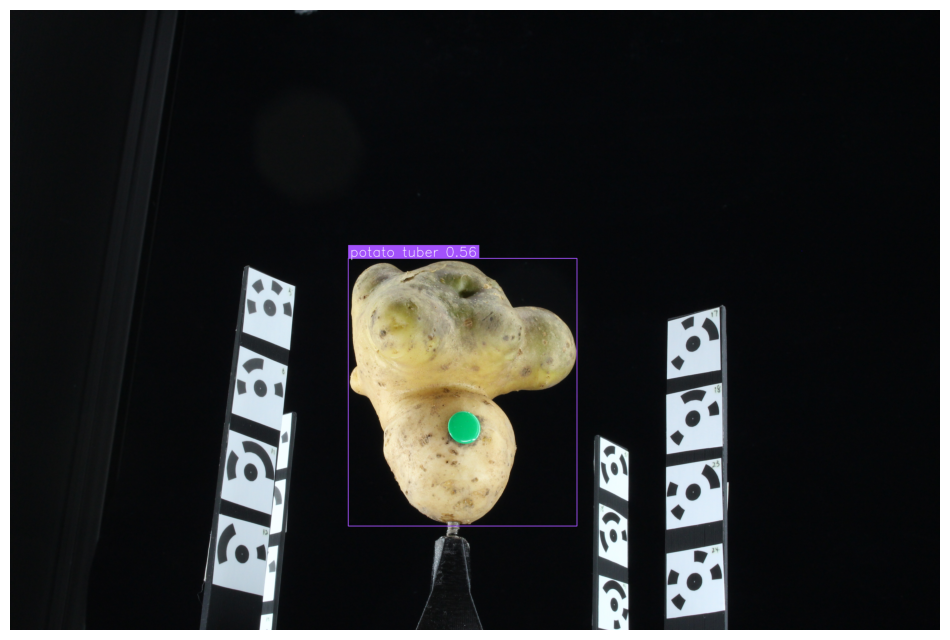

In [145]:
draw_gdino_results(image_pil, gdino_results[0])

In [58]:
def merge_boxes(gdino_results):
    # Extract the tensor containing all boxes
    all_boxes = gdino_results[0]['boxes']

    # Check if there are any boxes to merge
    if all_boxes.shape[0] > 0:
        # Find the min of all x1 and y1 coordinates
        min_xy = all_boxes[:, :2].min(dim=0).values
        
        # Find the max of all x2 and y2 coordinates
        max_xy = all_boxes[:, 2:].max(dim=0).values
        
        # Concatenate to form the merged bounding box
        merged_box = torch.cat([min_xy, max_xy])
        
        print("Merged BBox:", merged_box)

        return merged_box
    else:
        print("No bounding boxes to merge.")
        return None

In [146]:
bbox = merge_boxes(gdino_results)

bbox

Merged BBox: tensor([1885.1072, 1384.3519, 3160.5103, 2876.3569], device='cuda:0')


tensor([1885.1072, 1384.3519, 3160.5103, 2876.3569], device='cuda:0')

In [147]:
bbox_array = bbox.cpu().numpy()

bbox_array

array([     1885.1,      1384.4,      3160.5,      2876.4], dtype=float32)

```python
def predict(
        images_pil: list[Image.Image],
        texts_prompt: list[str],
        box_threshold: float = 0.3,
        text_threshold: float = 0.25,
    ):
        """Predicts masks for given images and text prompts using GDINO and SAM models.

        Parameters:
            images_pil (list[Image.Image]): List of input images.
            texts_prompt (list[str]): List of text prompts corresponding to the images.
            box_threshold (float): Threshold for box predictions.
            text_threshold (float): Threshold for text predictions.

        Returns:
            list[dict]: List of results containing masks and other outputs for each image.
            Output format:
            [{
                "boxes": np.ndarray,
                "scores": np.ndarray,
                "masks": np.ndarray,
                "mask_scores": np.ndarray,
            }, ...]
        """

        gdino_results = self.gdino.predict(images_pil, texts_prompt, box_threshold, text_threshold)
        all_results = []
        sam_images = []
        sam_boxes = []
        sam_indices = []
        for idx, result in enumerate(gdino_results):
            result = {k: (v.cpu().numpy() if hasattr(v, "numpy") else v) for k, v in result.items()}
            processed_result = {
                **result,
                "masks": [],
                "mask_scores": [],
            }

            if result["labels"]:
                sam_images.append(np.asarray(images_pil[idx]))
                sam_boxes.append(processed_result["boxes"])
                sam_indices.append(idx)

            all_results.append(processed_result)

        if sam_images:
            print(f"Predicting {len(sam_boxes)} masks")
            masks, mask_scores, _ = self.sam.predict_batch(sam_images, xyxy=sam_boxes)
            for idx, mask, score in zip(sam_indices, masks, mask_scores):
                all_results[idx].update(
                    {
                        "masks": mask,
                        "mask_scores": score,
                    }
                )
            print(f"Predicted {len(all_results)} masks")

        return all_results
````

interactive annotation by sam2 video tracking

In [60]:
from ultralytics.models.sam import SAM2DynamicInteractivePredictor

In [ ]:
sam2_overrides = dict(conf=0.01, task="segment", mode="predict", imgsz=1024, model="checkpoints/sam_models/sam2.1_b.pt", save=False)

In [ ]:
sam2_predictor = SAM2DynamicInteractivePredictor(overrides=sam2_overrides, max_obj_num=10)

In [ ]:
results = sam2_predictor(source=image_file,
          bboxes=[bbox.cpu().numpy()], obj_ids=[1], update_memory=True)


Ultralytics 8.3.204 🚀 Python-3.11.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24090MiB)
image 1/1 /home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160435_5485.jpg: 1024x1024 1 0, 156.7ms
Speed: 3.1ms preprocess, 156.7ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)


In [151]:
results[0].save()

'results_DSC_006_20251002_160435_5485.jpg'

In [69]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: '0'}
obb: None
orig_img: array([[[19, 17, 16],
        [18, 16, 15],
        [18, 17, 13],
        ...,
        [ 8,  6,  6],
        [ 9,  7,  7],
        [ 8,  6,  6]],

       [[20, 18, 17],
        [19, 17, 16],
        [18, 17, 13],
        ...,
        [ 8,  6,  6],
        [ 9,  7,  7],
        [ 8,  6,  6]],

       [[19, 17, 16],
        [20, 18, 17],
        [19, 18, 14],
        ...,
        [ 9,  7,  7],
        [ 9,  7,  7],
        [ 9,  7,  7]],

       ...,

       [[13, 11, 10],
        [12, 10,  9],
        [12, 10,  9],
        ...,
        [ 9,  9,  9],
        [ 8,  8,  8],
        [ 5,  5,  5]],

       [[13, 11, 10],
        [12, 10,  9],
        [12, 10,  9],
        ...,
        [ 8,  8,  8],
        [ 7,  7,  7],
        [ 6,  6,  6]],

       [[12, 10,  9],
        [11,  9,  8],
  

In [62]:
results[0].masks.data.shape

torch.Size([1, 3456, 5184])

On the next image

In [ ]:
results = sam2_predictor(source="/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160445_5511.jpg")


image 1/1 /home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160445_5511.jpg: 1024x1024 1 0, 128.4ms
Speed: 8.0ms preprocess, 128.4ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)


In [23]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: '0'}
obb: None
orig_img: array([[[19, 18, 14],
        [16, 15, 11],
        [16, 15, 11],
        ...,
        [ 7,  5,  4],
        [ 6,  4,  3],
        [ 7,  5,  4]],

       [[20, 19, 15],
        [18, 17, 13],
        [17, 16, 12],
        ...,
        [ 7,  5,  4],
        [ 7,  5,  4],
        [ 8,  6,  5]],

       [[18, 17, 13],
        [18, 17, 13],
        [18, 17, 13],
        ...,
        [ 7,  5,  4],
        [ 8,  6,  5],
        [ 9,  7,  6]],

       ...,

       [[13, 11, 11],
        [13, 11, 11],
        [12, 10, 10],
        ...,
        [ 7,  5,  4],
        [ 7,  5,  4],
        [ 7,  5,  4]],

       [[13, 11, 11],
        [13, 11, 11],
        [11,  9,  9],
        ...,
        [ 7,  5,  4],
        [ 6,  4,  3],
        [ 6,  4,  3]],

       [[13, 11, 10],
        [14, 12, 11],
  

In [24]:
results[0].save()

'results_DSC_006_20251002_160445_5511.jpg'

Add traditional masking method

In [124]:
import skimage as ski

In [126]:
def get_cv_mask(img_np, color_threshold=15, fill_ratio=0.001, remove_ratio=0.001):
    h,w,d = img_np.shape

    # convert to LAB color space
    lab_image = ski.color.rgb2lab(img_np)

    # get color channel
    a_channel = lab_image[:, :, 1]
    b_channel = lab_image[:, :, 2]

    # set channel threshold
    # color_threshold = 15  # 颜色阈值

    # 创建掩膜
    mask = np.logical_or(a_channel > color_threshold, b_channel > color_threshold)

    # fill holes in the mask
    filled_mask = ski.morphology.remove_small_holes(mask, area_threshold=h*w*fill_ratio)
    cleaned_mask = ski.morphology.remove_small_objects(filled_mask, min_size=h*w*remove_ratio)

    # 将掩膜应用于原始图像
    result = np.copy(img_np)
    result[~cleaned_mask] = 0

    return cleaned_mask, result

In [139]:
cv_mask, result = get_cv_mask(np.asarray(image_pil), 5, 0.05, 0.001)

In [133]:
def draw_cv_mask(image_np, mask, show=False):
    mask_reshaped = mask[np.newaxis, ...]

    boxes = sv.mask_to_xyxy(masks=mask_reshaped)

    # 创建 Detections 对象
    detections = sv.Detections(
        xyxy=boxes,
        mask=mask_reshaped
    )

    # 创建一个 MaskAnnotator 实例
    # 你可以自定义颜色、透明度等
    mask_annotator = sv.MaskAnnotator(
        color_lookup=sv.ColorLookup.INDEX,
        opacity=0.5
    )

    # 在原始图像的副本上进行绘制
    annotated_image = mask_annotator.annotate(
        scene=image_np.copy(), 
        detections=detections
    )

    # --- 4. 显示结果 ---

    # supervision 提供了方便的绘图函数
    if show:
        sv.plot_image(annotated_image, size=(10, 10))

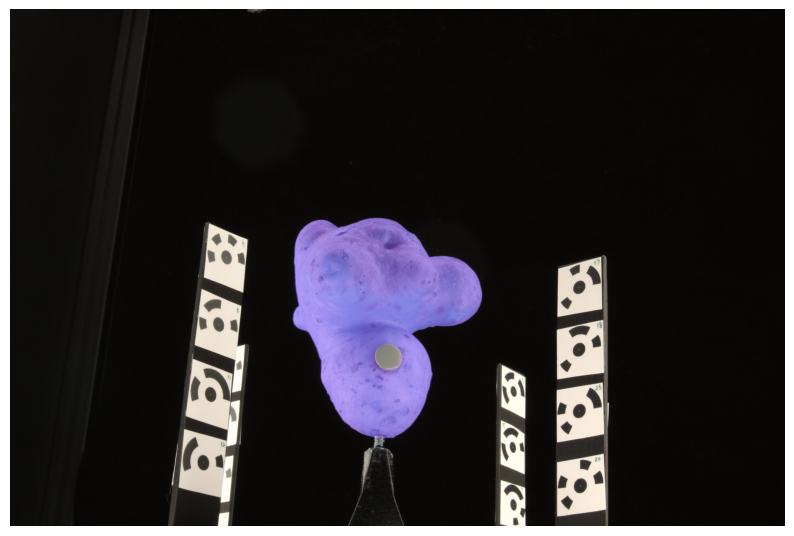

In [140]:
draw_cv_mask(np.asarray(image_pil), cv_mask, show=True)

gdino -> cvmask -> sam2

In [5]:
import torch
import numpy as np

from PIL import Image
import skimage as ski
import supervision as sv

from gdino import GDINO
from ultralytics.models.sam import SAM2DynamicInteractivePredictor

In [23]:
class ImageSegmenter():

    def __init__(self, detect_object:str, ):
        self.gdino_model = GDINO()
        self.gdino_model.build_model(device="cuda")

        self.detect_object = detect_object
        # self.texts_prompt = ". ".join(self.detect_objects)
        self.texts_prompt = detect_object

        self.sam2_overrides = dict(conf=0.01, task="segment", mode="predict", imgsz=1024, model="checkpoints/sam_models/sam2.1_b.pt", save=False)
        self.sam2_predictor = SAM2DynamicInteractivePredictor(overrides=self.sam2_overrides, max_obj_num=10)

    def apply(self, 
              image_file:str, 
              hsv_threshold=5, hole_fill_ratio=0.05, noise_remove_ratio=0.001, 
              sam2_track=False):
        
        image_pil  = Image.open(image_file)
        image_np   = np.asarray(image_pil)

        if not sam2_track:
            # begining SAM2 tracking

            # obtain the bbox
            gdino_result = self.get_gdino_bbox(image_pil)
            merged_bbox = self.merge_boxes_of_one_object(gdino_result, self.detect_object)

            gdino_detect_prev = self.draw_gdino_results(image_pil, gdino_result)

            if merged_bbox is None:
                # not have merged detections, execute source cv mask
                print("   => cv mask on full image")
                cleaned_mask = self.get_cv_mask(image_np, hsv_threshold=hsv_threshold, fill_ratio=hole_fill_ratio, remove_ratio=noise_remove_ratio)

            else:
                # have merged detections, execute the cv mask only in detection area
                image_np_in_bbox, np_bbox = self.crop_image_from_bbox(image_np, merged_bbox)
                x_min, y_min, x_max, y_max = np_bbox
                print(f"   => cv mask on bbox {np_bbox}")

                cleaned_mask_in_bbox = self.get_cv_mask(image_np_in_bbox, hsv_threshold=hsv_threshold, fill_ratio=hole_fill_ratio, remove_ratio=noise_remove_ratio)

                cleaned_mask = np.zeros( (image_np.shape[0], image_np.shape[1]), dtype=bool)
                cleaned_mask[y_min:y_max, x_min:x_max] = cleaned_mask_in_bbox

            cv_mask_prev = self.draw_cv_mask_results(image_pil, cleaned_mask)

            results = self.sam2_predictor(
                source=image_file,
                bboxes=[merged_bbox.cpu().numpy()], 
                masks=[cleaned_mask], 
                obj_ids=[1], 
                update_memory=True)
            
            return gdino_detect_prev, cv_mask_prev, results
            
        else:
            results = self.sam2_predictor(source=image_file)

            return results


    def get_gdino_bbox(self, image_pil, box_threshold=0.3, text_threshold=0.25):
        self.gdino_results = self.gdino_model.predict([image_pil], [self.texts_prompt], box_threshold=box_threshold, text_threshold=text_threshold)
        return self.gdino_results[0]


    def merge_boxes_of_one_object(self, gdino_result, object_name):
        # Extract the tensor containing all boxes
        all_boxes = gdino_result['boxes']
        labels_array = np.array(gdino_result['text_labels'])

        index_torch = torch.from_numpy(labels_array == object_name)

        # Check if there are any boxes to merge
        if index_torch.sum() > 0:
            # Find the min of all x1 and y1 coordinates
            min_xy = all_boxes[index_torch, :2].min(dim=0).values
            
            # Find the max of all x2 and y2 coordinates
            max_xy = all_boxes[index_torch, 2:].max(dim=0).values
            
            # Concatenate to form the merged bounding box
            merged_box = torch.cat([min_xy, max_xy])
            
            print(f"   Merged BBox for object [{object_name}]", merged_box)

            return merged_box
        else:
            print(f"   No bounding boxes to merge for object [{object_name}]")
            return None
        
    @staticmethod
    def get_cv_mask(img_np, hsv_threshold=15, fill_ratio=0.001, remove_ratio=0.001):
        h,w,d = img_np.shape

        # convert to LAB color space
        lab_image = ski.color.rgb2lab(img_np)

        # get color channel
        a_channel = lab_image[:, :, 1]
        b_channel = lab_image[:, :, 2]

        # set channel threshold
        # color_threshold = 15  # 颜色阈值

        # 创建掩膜
        mask = np.logical_or(a_channel > hsv_threshold, b_channel > hsv_threshold)

        # fill holes in the mask
        filled_mask = ski.morphology.remove_small_holes(mask, area_threshold=h*w*fill_ratio)
        cleaned_mask = ski.morphology.remove_small_objects(filled_mask, min_size=h*w*remove_ratio)

        # 将掩膜应用于原始图像
        # result = np.copy(img_np)
        # result[~cleaned_mask] = 0

        return cleaned_mask
    
    @staticmethod
    def crop_image_from_bbox(image_arr: np.ndarray, bbox: list[int]) -> np.ndarray:
        """
        Extracts a region from a NumPy array based on a bounding box.

        The bounding box is expected in the "DL xyxy" format, which is
        [x_min, y_min, x_max, y_max].

        Args:
            image_arr: The source image as a NumPy array (H, W, C) or (H, W).
            bbox: A list or tuple of integers representing the bounding box
                coordinates [x_min, y_min, x_max, y_max].

        Returns:
            A new NumPy array representing the cropped region of the image.
        """
        # Unpack the bounding box coordinates
        x_min, y_min, x_max, y_max = bbox

        # Ensure coordinates are integers for slicing
        x_min, y_min = int(x_min), int(y_min)
        x_max, y_max = int(x_max), int(y_max)

        # Perform the slicing. NumPy's slicing is [y_start:y_end, x_start:x_end]
        # Note that the 'end' index is exclusive in Python slicing.
        cropped_arr = image_arr[y_min:y_max, x_min:x_max]
        
        return cropped_arr, [x_min, y_min, x_max, y_max]


    @staticmethod
    def draw_gdino_results(image, gdino_result, show=False):
        # 2. Extract and convert data
        # The tensors are on the GPU, so we need to move them to the CPU and convert to NumPy
        boxes = gdino_result['boxes'].cpu().numpy()
        scores = gdino_result['scores'].cpu().numpy()
        text_labels = gdino_result['text_labels']

        # Create class_id for each unique label
        unique_labels = list(set(text_labels))
        class_id_map = {label: idx for idx, label in enumerate(unique_labels)}
        class_id = [class_id_map[label] for label in text_labels]

        # 3. Create a supervision.Detections object
        detections = sv.Detections(
            xyxy=boxes,
            confidence=scores,
            class_id=np.array(class_id)
        )

        # 5. Create Annotators
        box_annotator = sv.BoxAnnotator(thickness=4)
        label_annotator = sv.LabelAnnotator(text_scale=2.5, text_thickness=2)

        # 6. Create custom labels for visualization
        # We'll combine the text label with the confidence score
        labels = [
            f"{label} {confidence:.2f}"
            for label, confidence
            in zip(text_labels, scores)
        ]

        # 7. Annotate the image
        annotated_image = box_annotator.annotate(
            scene=image.copy(),
            detections=detections
        )
        annotated_image = label_annotator.annotate(
            scene=annotated_image,
            detections=detections,
            labels=labels
        )

        # 8. Display or save the annotated image
        if show:
            sv.plot_image(annotated_image, size=(12, 12))
        
        return annotated_image
    

    @staticmethod
    def draw_cv_mask_results(image_np, mask, show=False):
        mask_reshaped = mask[np.newaxis, ...]

        boxes = sv.mask_to_xyxy(masks=mask_reshaped)

        # 创建 Detections 对象
        detections = sv.Detections(
            xyxy=boxes,
            mask=mask_reshaped
        )

        # 创建一个 MaskAnnotator 实例
        # 你可以自定义颜色、透明度等
        mask_annotator = sv.MaskAnnotator(
            color_lookup=sv.ColorLookup.INDEX,
            opacity=0.8
        )

        # 在原始图像的副本上进行绘制
        annotated_image = mask_annotator.annotate(
            scene=image_np.copy(), 
            detections=detections
        )

        # --- 4. 显示结果 ---

        # supervision 提供了方便的绘图函数
        if show:
            sv.plot_image(annotated_image, size=(10, 10))

        return annotated_image

Tests

In [7]:
image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160444_5510.jpg"
# image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160435_5485.jpg"
# image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/084/001/DSC_001_20251002_160325_5370.jpg"
# image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/084/004/DSC_004_20251002_160326_5373.jpg"

In [29]:
imgseg = ImageSegmenter(detect_object="potato tuber")

One or both local paths not provided. Loading from Hugging Face Hub: IDEA-Research/grounding-dino-base


In [30]:
prev1, prev2, results = imgseg.apply(image_file)

   Merged BBox for object [potato tuber] tensor([1802.1949, 1428.4823, 3133.0139, 2867.9099], device='cuda:0')
   => cv mask on bbox [1802, 1428, 3133, 2867]

Ultralytics 8.3.204 🚀 Python-3.11.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24090MiB)
image 1/1 /home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160444_5510.jpg: 1024x1024 1 0, 153.9ms
Speed: 2.8ms preprocess, 153.9ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)


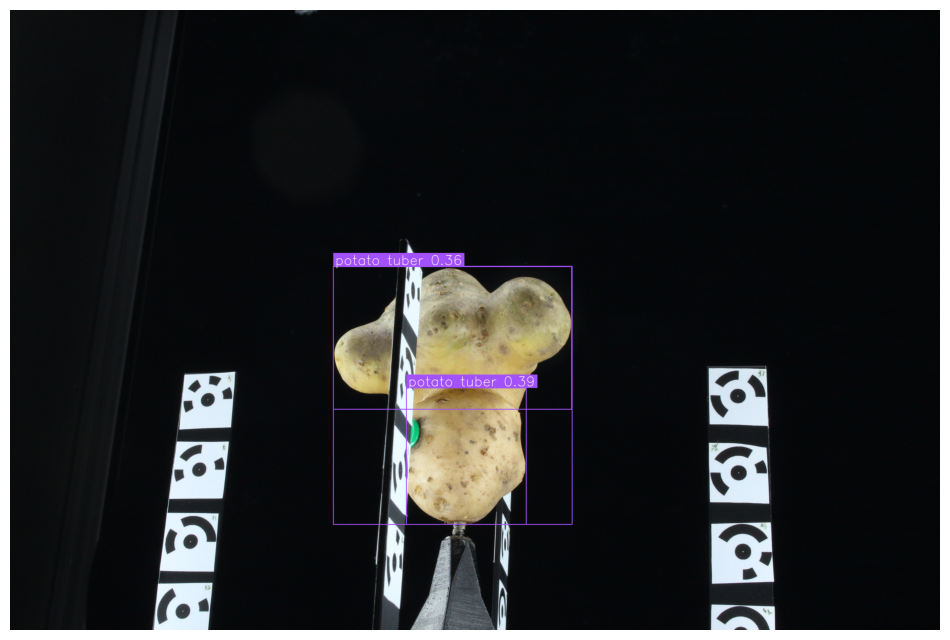

In [26]:
sv.plot_image(prev1)

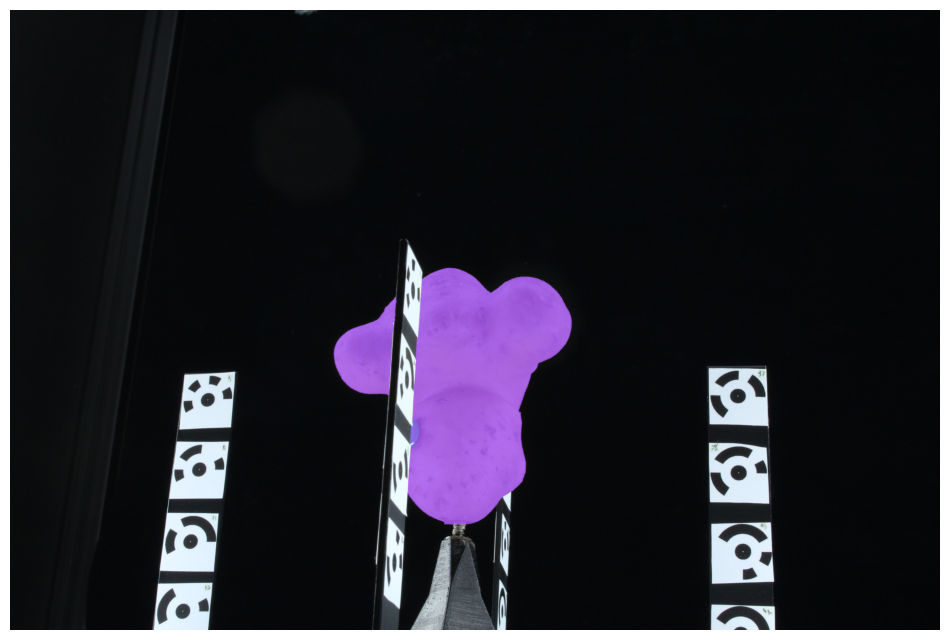

In [11]:
sv.plot_image(prev2)

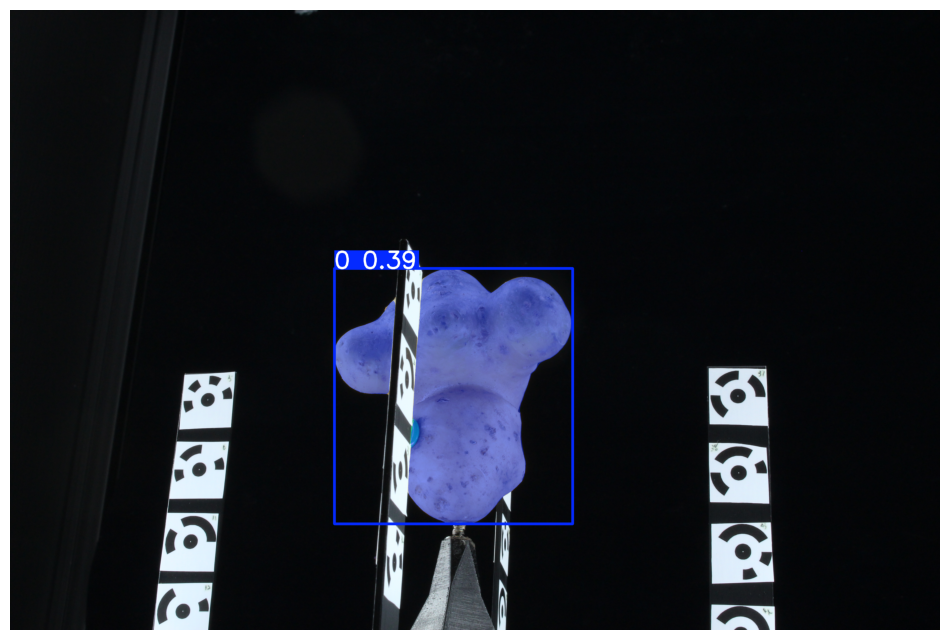

In [12]:
sv.plot_image(results[0].plot())

In [13]:
results[0].masks.data.cpu().numpy()*255

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 3456, 5184))


image 1/1 /home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160445_5511.jpg: 1024x1024 1 0, 126.3ms
Speed: 3.8ms preprocess, 126.3ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)


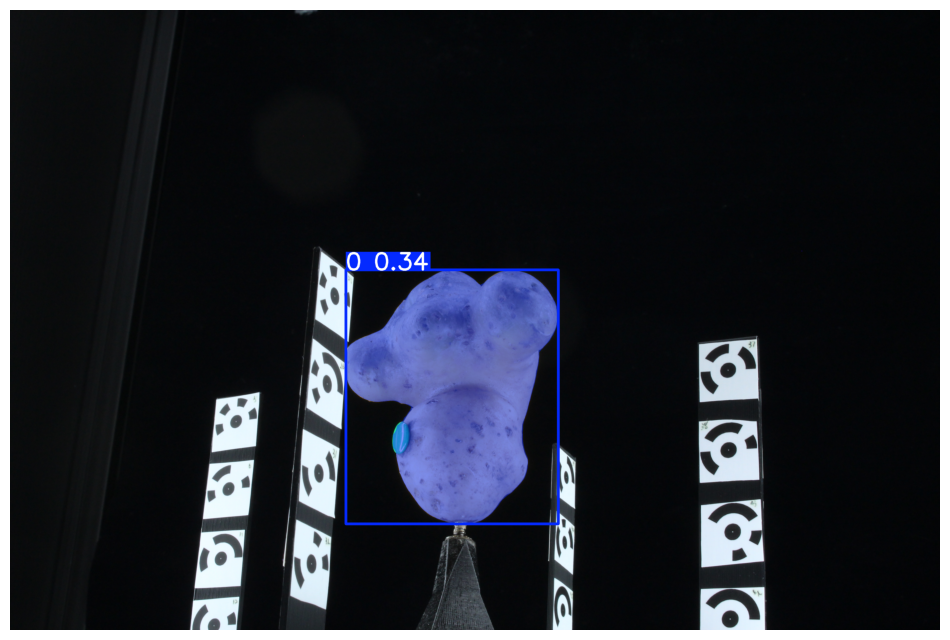

In [32]:
results2 = imgseg.apply(
    image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160445_5511.jpg",
    sam2_track=True
)

sv.plot_image(results2[0].plot())


image 1/1 /home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160448_5519.jpg: 1024x1024 1 0, 125.9ms
Speed: 8.8ms preprocess, 125.9ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)


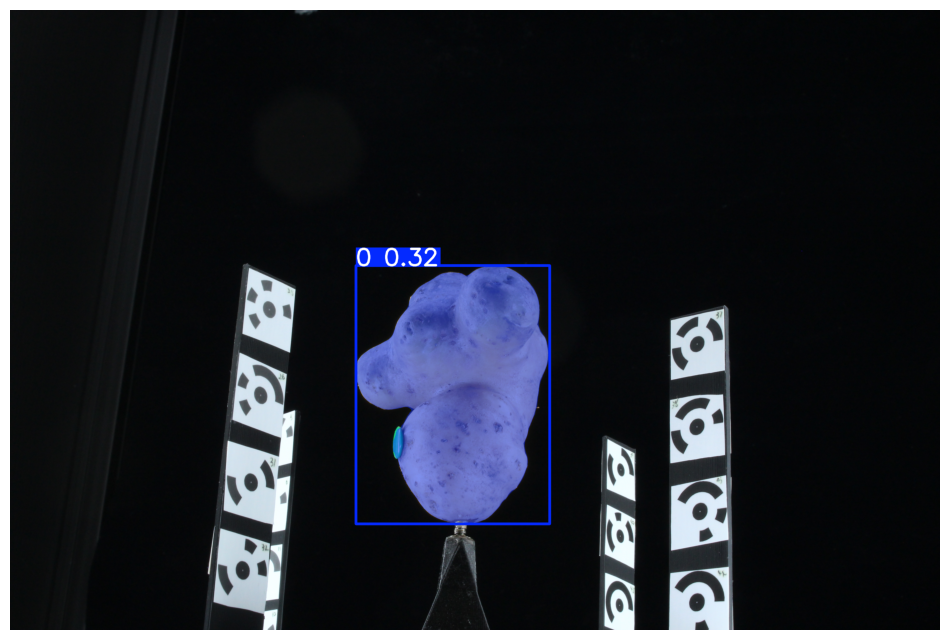

In [33]:
results2 = imgseg.apply(
    image_file = "/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160448_5519.jpg",
    sam2_track=True
)

sv.plot_image(results2[0].plot())

In [14]:
from cascade_psp import Refiner

psp_model_path = 'checkpoints/psp_models/cascade_psp'

psp_refiner = Refiner(device='cuda:0', model_path=psp_model_path)

In [15]:
img_np = ski.io.imread(image_file)

mask = results[0].masks.data.cpu().numpy().squeeze()*255

In [16]:
psp_mask = psp_refiner.refine(img_np, mask, fast=False, L=900)

In [17]:
psp_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3456, 5184), dtype=uint8)

In [18]:
psp_mask.max()

np.uint8(255)

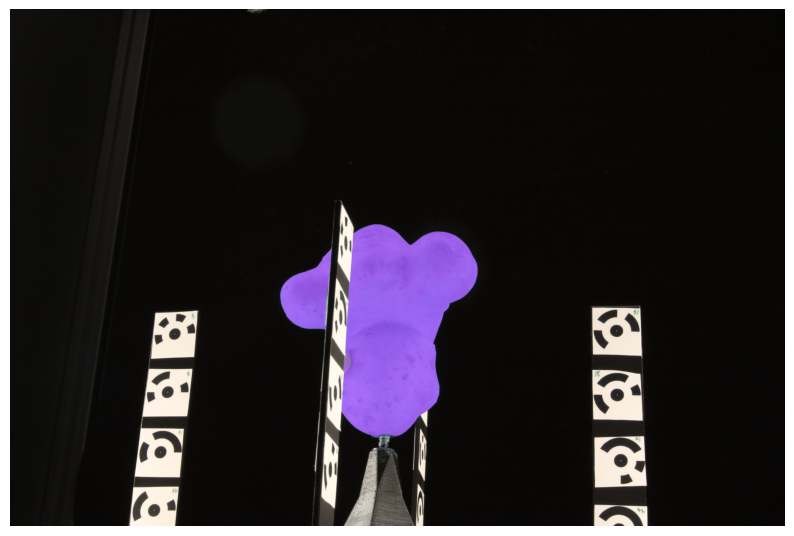

array([[[16, 17, 19],
        [15, 16, 18],
        [13, 17, 18],
        ...,
        [ 6,  6,  8],
        [ 7,  7,  9],
        [ 6,  6,  8]],

       [[17, 18, 20],
        [16, 17, 19],
        [13, 17, 18],
        ...,
        [ 6,  6,  8],
        [ 7,  7,  9],
        [ 6,  6,  8]],

       [[16, 17, 19],
        [17, 18, 20],
        [14, 18, 19],
        ...,
        [ 7,  7,  9],
        [ 7,  7,  9],
        [ 7,  7,  9]],

       ...,

       [[10, 11, 13],
        [ 9, 10, 12],
        [ 9, 10, 12],
        ...,
        [ 9,  9,  9],
        [ 8,  8,  8],
        [ 5,  5,  5]],

       [[10, 11, 13],
        [ 9, 10, 12],
        [ 9, 10, 12],
        ...,
        [ 8,  8,  8],
        [ 7,  7,  7],
        [ 6,  6,  6]],

       [[ 9, 10, 12],
        [ 8,  9, 11],
        [ 9, 10, 12],
        ...,
        [ 6,  6,  6],
        [ 6,  6,  6],
        [ 5,  5,  5]]], shape=(3456, 5184, 3), dtype=uint8)

In [19]:
imgseg.draw_cv_mask_results(img_np, psp_mask==255, True)